# Experiment Analysis

In [25]:
# Cell 1: Imports and Robust Path Setup
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import numpy as np
import tensorflow as tf
import keras
import matplotlib.cm as cm
import cv2
import glob
import random
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
import shutil


# --- 1. ROBUST PATH RESOLUTION ---
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
LOGS_DIR = os.path.join(PROJECT_ROOT, "logs")

# Add project root to sys.path so we can import our custom modules!
sys.path.append(PROJECT_ROOT)

# --- 2. HARDWARE CONFIGURATION ---
from src.utils import load_config
# Load the laptop profile to prevent CUDA crashes
cfg = load_config(profile="laptop")

if not cfg['use_gpu']:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
    print("💻 [CONFIG] LAPTOP MODE ACTIVE: GPU Disabled for Notebook")
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
    print("🚀 [CONFIG] DESKTOP MODE ACTIVE: GPU Enabled for Notebook")

# --- 3. VISUAL THEME ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

print(f"📁 Project Root found at: {PROJECT_ROOT}")

print(f"📁 Logs Directory mapped to: {LOGS_DIR}")

💻 [CONFIG] LAPTOP MODE ACTIVE: GPU Disabled for Notebook
📁 Project Root found at: /home/victor/workspace/utils/TinyImageNet_Project
📁 Logs Directory mapped to: /home/victor/workspace/utils/TinyImageNet_Project/logs


In [2]:
# Cell 2: Robust MLOps CSV Loader (Crash-Proof)
import csv

logs_path = os.path.join(LOGS_DIR, "experiment_logs.csv")

if os.path.exists(logs_path):
    # 1. Read the file using Python's forgiving CSV reader
    with open(logs_path, 'r') as f:
        reader = csv.reader(f)
        raw_data = list(reader)

    if len(raw_data) > 0:
        # 2. Extract the header and the data rows
        header = raw_data[0]
        rows = raw_data[1:]

        # 3. Find the maximum row length in the entire file
        max_cols = max(len(row) for row in raw_data)

        # 4. If any rows are longer than the header, expand the header dynamically!
        if len(header) < max_cols:
            for i in range(len(header), max_cols):
                header.append(f"New_Col_{i}")

        # 5. Pad any short rows with 'None' (NaN) so they don't crash Pandas
        padded_rows = []
        for row in rows:
            if len(row) < max_cols:
                row.extend([None] * (max_cols - len(row)))
            padded_rows.append(row)

        # 6. Convert to Pandas DataFrame safely
        df_logs = pd.DataFrame(padded_rows, columns=header)
        
        # Display the result
        print("✅ Data loaded successfully with Schema Healing!")
        display(df_logs.head())
    else:
        print("CSV is empty!")
else:
    print(f"⚠️ Could not find {logs_path}.")

✅ Data loaded successfully with Schema Healing!


,Profile,Date,Start_Time,End_Time,Duration,Model,Pretrained,Epochs_Run,Train_Loss,Train_Accuracy,Val_Loss,Val_Accuracy,Dropout_Rate,Learning_Rate,Batch_Size,Weight_Decay,Label_Smoothing
0,LAPTOP,05/03/2026,08:37,08:56,0h 18m,VIT,False,1,5.0477,0.0316,4.7789,0.0622,0.3,0.001,16,1e-4,0.1
1,LAPTOP,05/03/2026,09:49,10:23,0h 34m,VIT,False,2,4.8259,0.0546,4.6881,0.0776,0.3,0.001,16,1e-4,0.1


In [8]:
# Cell 2.5: Aggregate MLOps Analysis Dashboard
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display, Markdown
import pandas as pd

# ==========================================
# 1. DATA ENGINEERING: FEATURE PREPARATION
# ==========================================
if 'df_logs' not in locals() or df_logs.empty:
    print("⚠️ Please run Cell 2 first to load the experiment_logs.csv data!")
else:
    df_analysis = df_logs.copy()
    
    # --- THE BUG FIX: Force columns to be numeric floats ---
    # We list all the columns that MUST be numbers for our graphs to work
    numeric_columns = [
        'Train_Accuracy', 'Val_Accuracy', 'Train_Loss', 'Val_Loss', 
        'Epochs_Run', 'Learning_Rate', 'Dropout_Rate', 'Batch_Size', 
        'Weight_Decay', 'Label_Smoothing'
    ]
    
    # 'coerce' tells Pandas: "If you find text you can't convert to a number, just turn it into NaN (blank)"
    for col in numeric_columns:
        if col in df_analysis.columns:
            df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')
            
    # Drop any rows where the core metrics got turned into NaN (corrupted rows)
    df_analysis = df_analysis.dropna(subset=['Train_Accuracy', 'Val_Accuracy'])
    
    # --- Calculate the Generalization Gap ---
    df_analysis['Gen_Gap'] = df_analysis['Train_Accuracy'] - df_analysis['Val_Accuracy']
    
    # --- Parse Duration into Mathematical Minutes ---
    def parse_time_to_minutes(time_str):
        try:
            parts = str(time_str).split('h')
            hours = int(parts[0].strip())
            minutes = int(parts[1].replace('m', '').strip())
            return (hours * 60) + minutes
        except:
            return 0 
            
    df_analysis['Duration_Mins'] = df_analysis['Duration'].apply(parse_time_to_minutes)
    df_analysis['Run_ID'] = df_analysis['Model'] + " (" + df_analysis['Date'].astype(str) + " " + df_analysis['Start_Time'].astype(str) + ")"

# ==========================================
# 2. VISUALIZATION 1: GENERALIZATION GAP
# ==========================================
    fig_gap = go.Figure(data=[
        go.Bar(name='Train Accuracy', x=df_analysis['Run_ID'], y=df_analysis['Train_Accuracy'], marker_color='royalblue'),
        go.Bar(name='Val Accuracy', x=df_analysis['Run_ID'], y=df_analysis['Val_Accuracy'], marker_color='darkorange')
    ])
    
    fig_gap.add_trace(go.Scatter(
        name='Overfitting Gap', 
        x=df_analysis['Run_ID'], 
        y=df_analysis['Gen_Gap'], 
        mode='lines+markers',
        line=dict(color='red', width=2, dash='dot'),
        yaxis='y2' 
    ))

    fig_gap.update_layout(
        title="<b>1️⃣ & 2️⃣ Train vs Validation & Generalization Gap</b>",
        barmode='group',
        template="plotly_white",
        yaxis=dict(title='Accuracy'),
        yaxis2=dict(title='Gap Size', overlaying='y', side='right', showgrid=False), 
        hovermode="x unified"
    )
    fig_gap.show()

# ==========================================
# 3. VISUALIZATION 2: EFFICIENCY (ACC VS TIME)
# ==========================================
    fig_time = px.scatter(
        df_analysis, 
        x='Duration_Mins', 
        y='Val_Accuracy', 
        color='Model', 
        size='Epochs_Run', 
        hover_data=['Profile', 'Batch_Size'],
        title="<b>3️⃣ Efficiency: Accuracy vs Training Time</b>",
        labels={"Duration_Mins": "Training Time (Minutes)", "Val_Accuracy": "Validation Accuracy"},
        template="plotly_white"
    )
    
    fig_time.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
    fig_time.show()

# ==========================================
# 4. VISUALIZATION 3: HYPERPARAMETER INFLUENCE
# ==========================================
    fig_params = go.Figure(data=
        go.Parcoords(
            line=dict(color=df_analysis['Val_Accuracy'], colorscale='Viridis', showscale=True, cmin=df_analysis['Val_Accuracy'].min(), cmax=df_analysis['Val_Accuracy'].max()),
            dimensions=[
                dict(label='Learning Rate', values=df_analysis['Learning_Rate']),
                dict(label='Dropout Rate', values=df_analysis['Dropout_Rate']),
                dict(label='Batch Size', values=df_analysis['Batch_Size']),
                dict(label='Weight Decay', values=df_analysis['Weight_Decay']),
                dict(label='Val Accuracy (Target)', values=df_analysis['Val_Accuracy'])
            ]
        )
    )
    fig_params.update_layout(
        title="<b>4️⃣ Hyperparameter Influence Flow</b>",
        template="plotly_white",
        height=400
    )
    fig_params.show()

# ==========================================
# 4.5 NEW VISUALIZATION: CORRELATION MATRIX
# ==========================================
    # Isolate the numeric columns that actually impact performance
    corr_cols = ['Val_Accuracy', 'Learning_Rate', 'Dropout_Rate', 'Batch_Size', 'Weight_Decay', 'Label_Smoothing']
    df_corr = df_analysis[corr_cols].corr()

    fig_corr = px.imshow(
        df_corr,
        text_auto=".2f", 
        color_continuous_scale='RdBu_r', 
        title="<b>🔍 Hyperparameter Correlation Matrix</b>",
        height=500
    )
    fig_corr.show()

# ==========================================
# 4.6 NEW VISUALIZATION: COMPUTATIONAL THROUGHPUT & ROI
# ==========================================
    df_analysis['Mins_Per_Epoch'] = df_analysis['Duration_Mins'] / df_analysis['Epochs_Run']
    df_analysis['Acc_Per_Minute'] = df_analysis['Val_Accuracy'] / df_analysis['Duration_Mins'].replace(0, 1) 

    fig_cost = make_subplots(specs=[[{"secondary_y": True}]])

    fig_cost.add_trace(
        go.Bar(x=df_analysis['Run_ID'], y=df_analysis['Mins_Per_Epoch'], name="Minutes per Epoch", marker_color='lightslategray'),
        secondary_y=False,
    )

    fig_cost.add_trace(
        go.Scatter(x=df_analysis['Run_ID'], y=df_analysis['Acc_Per_Minute'], name="ROI (Acc / Min)", mode='lines+markers', line=dict(color='mediumseagreen', width=3)),
        secondary_y=True,
    )

    fig_cost.update_layout(
        title="<b>⏱️ Computational Cost & Business ROI</b>",
        template="plotly_white",
        hovermode="x unified"
    )
    fig_cost.update_yaxes(title_text="Minutes per Epoch", secondary_y=False)
    fig_cost.update_yaxes(title_text="Accuracy per Minute", secondary_y=True)
    
    fig_cost.show()

# ==========================================
# 5. BEST CONFIGURATION TABLE
# ==========================================
    if not df_analysis.empty:
        best_run = df_analysis.sort_values(by="Val_Accuracy", ascending=False).iloc[0]
        
        display(Markdown("### 🏆 5️⃣ Best Overall Configuration"))
        
        best_config_summary = pd.DataFrame({
            "Metric": ["👑 Winning Model", "🎯 Peak Val Accuracy", "⏱️ Training Time", "🧠 Epochs Required", "⚙️ Best Learning Rate", "📉 Best Dropout", "📦 Best Batch Size"],
            "Value": [
                best_run['Model'], 
                f"{best_run['Val_Accuracy']*100:.2f}%", 
                best_run['Duration'], 
                best_run['Epochs_Run'],
                best_run['Learning_Rate'],
                best_run['Dropout_Rate'],
                best_run['Batch_Size']
            ]
        })
        
        display(best_config_summary.style.hide(axis="index").set_properties(**{'text-align': 'left', 'font-size': '14px'}))

### 🏆 5️⃣ Best Overall Configuration

Metric,Value
👑 Winning Model,VIT
🎯 Peak Val Accuracy,7.76%
⏱️ Training Time,0h 34m
🧠 Epochs Required,2
⚙️ Best Learning Rate,0.001000
📉 Best Dropout,0.300000
📦 Best Batch Size,16


📊 Found 1 training histories. Generating plots from lowest to highest accuracy...



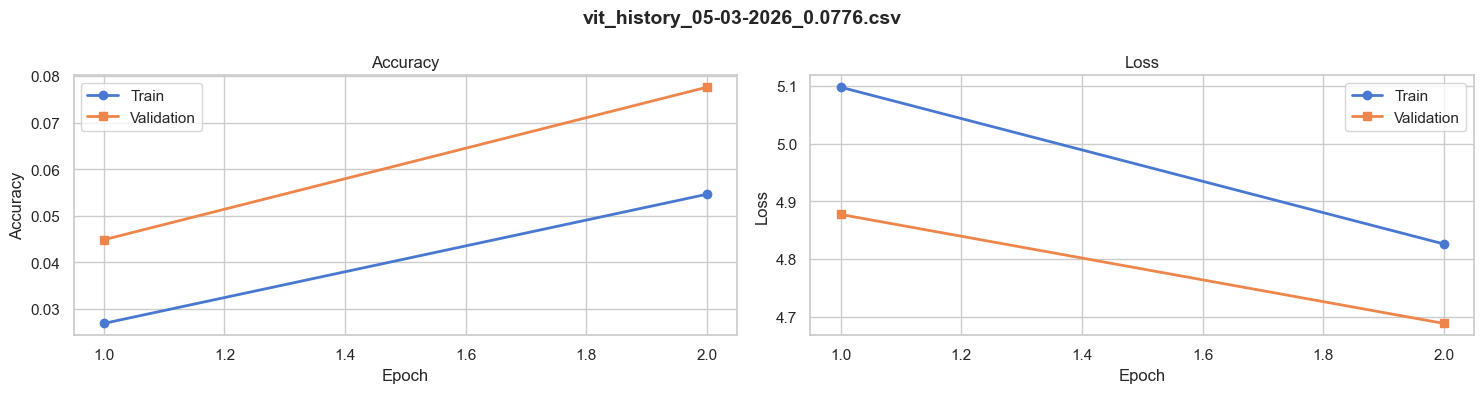

In [4]:
# Cell 3: Automated Training History Visualization
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Find all history CSV files in the logs directory (ignore the master tracker)
history_files = [f for f in os.listdir(LOGS_DIR) if f.endswith('.csv') and f != 'experiment_logs.csv']

if not history_files:
    print(f"⚠️ No training history files found in {LOGS_DIR}.")
else:
    plot_data = []
    
    # 2. Load all files and extract their best validation accuracy for sorting
    for filename in history_files:
        file_path = os.path.join(LOGS_DIR, filename)
        df = pd.read_csv(file_path)
        
        # Safely get the max validation accuracy
        best_val = df['val_accuracy'].max() if 'val_accuracy' in df.columns else 0.0
        
        # Store as a tuple: (accuracy, filename, dataframe) so we can sort it!
        plot_data.append((best_val, filename, df))
        
    # 3. Sort the list of tuples based on the first item (best_val) from smallest to largest
    plot_data.sort(key=lambda x: x[0])
    
    print(f"📊 Found {len(plot_data)} training histories. Generating plots from lowest to highest accuracy...\n")
    
    # 4. Generate the plots in the sorted order
    for best_val, filename, df in plot_data:
        # Create a figure with 2 subplots (1 row, 2 columns)
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))
        
        # Use the exact filename as the title, as requested!
        fig.suptitle(f"{filename}", fontsize=14, fontweight='bold')

        # --- Plot 1: Accuracy ---
        axes[0].plot(df['epoch'], df['accuracy'], label='Train', marker='o', linewidth=2)
        if 'val_accuracy' in df.columns:
            axes[0].plot(df['epoch'], df['val_accuracy'], label='Validation', marker='s', linewidth=2)
        axes[0].set_title('Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()

        # --- Plot 2: Loss ---
        axes[1].plot(df['epoch'], df['loss'], label='Train', marker='o', linewidth=2)
        if 'val_loss' in df.columns:
            axes[1].plot(df['epoch'], df['val_loss'], label='Validation', marker='s', linewidth=2)
        axes[1].set_title('Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

In [5]:
# Cell 3: Interactive Training History (Plotly)

# Force Plotly to render inside a secure iframe so Jupyter Lab doesn't block it
pio.renderers.default = 'iframe' 

# 1. Find all history CSV files in the logs directory
history_files = [f for f in os.listdir(LOGS_DIR) if f.endswith('.csv') and f != 'experiment_logs.csv']

if not history_files:
    print(f"⚠️ No training history files found in {LOGS_DIR}.")
else:
    plot_data = []
    
    # 2. Load and sort the files by best validation accuracy
    for filename in history_files:
        file_path = os.path.join(LOGS_DIR, filename)
        df = pd.read_csv(file_path)
        best_val = df['val_accuracy'].max() if 'val_accuracy' in df.columns else 0.0
        plot_data.append((best_val, filename, df))
        
    plot_data.sort(key=lambda x: x[0])
    
    print(f"📈 Found {len(plot_data)} training histories. Generating interactive plots...\n")
    
    # 3. Generate the Interactive Plots
    for best_val, filename, df in plot_data:
        # Create a subplot with 1 row and 2 columns
        fig = make_subplots(rows=1, cols=2, subplot_titles=("Model Accuracy", "Model Loss"))
        
        # --- Plot 1: Accuracy ---
        fig.add_trace(
            go.Scatter(x=df['epoch'], y=df['accuracy'], mode='lines+markers', name='Train Acc', line=dict(color='blue')),
            row=1, col=1
        )
        if 'val_accuracy' in df.columns:
            fig.add_trace(
                go.Scatter(x=df['epoch'], y=df['val_accuracy'], mode='lines+markers', name='Val Acc', line=dict(color='orange')),
                row=1, col=1
            )

        # --- Plot 2: Loss ---
        fig.add_trace(
            go.Scatter(x=df['epoch'], y=df['loss'], mode='lines+markers', name='Train Loss', line=dict(color='red')),
            row=1, col=2
        )
        if 'val_loss' in df.columns:
            fig.add_trace(
                go.Scatter(x=df['epoch'], y=df['val_loss'], mode='lines+markers', name='Val Loss', line=dict(color='green')),
                row=1, col=2
            )

        # 4. Make it beautiful and interactive
        fig.update_layout(
            title_text=f"<b>{filename}</b>",
            title_x=0.5,
            height=450,
            width=1000,
            hovermode="x unified", 
            template="plotly_white",
            showlegend=True
        )
        
        fig.update_xaxes(title_text="Epoch", row=1, col=1)
        fig.update_xaxes(title_text="Epoch", row=1, col=2)
        fig.update_yaxes(title_text="Accuracy", row=1, col=1)
        fig.update_yaxes(title_text="Loss", row=1, col=2)

        # Display the interactive graph
        fig.show()

📈 Found 1 training histories. Generating interactive plots...



## How Grad-CAM Works

Instead of looking at the final output prediction, Grad-CAM looks at the mathematical gradients flowing into the last convolutional layer of the network. It essentially asks the network: "Which specific pixels caused the highest spike in your final decision?" It then generates a thermal heatmap over the original image.

(Note: Because Vision Transformers use Attention instead of Convolutions, they require a different technique called "Attention Rollout". For this step, we will use your saved EfficientNet model, as Grad-CAM is perfectly designed for CNNs).

In [6]:
# Cell 4: Grad-CAM Core Algorithm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """
    Records the mathematical gradients of the model to generate a spatial heatmap.
    """
    # 1. We hook DIRECTLY into the last convolutional layer of the network
    last_conv_layer = model.get_layer(last_conv_layer_name)
    
    # 2. We create a "sub-model" that outputs BOTH the last convolutional layer's features 
    # AND the final 200-class prediction
    grad_model = keras.models.Model(
        inputs=[model.inputs],
        outputs=[last_conv_layer.output, model.output]
    )

    # 3. We use GradientTape to mathematically "record" the operations
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Calculate the gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Pool the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Multiply feature map by importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

print("✅ Grad-CAM Algorithm successfully loaded!")

✅ Grad-CAM Algorithm successfully loaded!


In [ ]:
# Cell 5: Automated Saliency Map with Human-Readable Labels
import cv2 
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import keras

# ==========================================
# 1. AUTOMATED PATH CONFIGURATION
# ==========================================
# Define the absolute paths to the project root and necessary folders
MODEL_PATH = os.path.join(PROJECT_ROOT, "models", "efficientnet_best.keras")
TRAIN_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "train")
VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")
WORDS_PATH = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "words.txt")

# ==========================================
# 2. DICTIONARY MAPPING (IDs -> English Words)
# ==========================================
label_map = {}
# Tiny ImageNet uses WordNet IDs (like 'n01443537'). 
# We must read words.txt to translate these IDs into human words.
if os.path.exists(WORDS_PATH):
    with open(WORDS_PATH, "r") as f:
        for line in f:
            # The file is separated by tabs. Example: "n01443537 \t goldfish, Carassius..."
            parts = line.strip().split("\t")
            if len(parts) == 2:
                # We split by comma and take index [0] to get the shortest, most common name
                label_map[parts[0]] = parts[1].split(",")[0] 

# ==========================================
# 3. RECREATING THE MODEL'S INTERNAL BRAIN
# ==========================================
# During training, Keras assigned a number (0-199) to each class by sorting the TRAIN folders alphabetically.
# We must perfectly recreate this list to translate the model's numerical output back into a folder name.
class_folders = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
class_names = sorted(class_folders) # This guarantees index 0 matches Keras's index 0

# ==========================================
# 4. RANDOM IMAGE SELECTION
# ==========================================
# We use glob to deeply scan the validation folder and find every single .JPEG file
all_images = glob.glob(os.path.join(VAL_DIR, "**", "*.JPEG"), recursive=True)

if not os.path.exists(MODEL_PATH):
    print(f"⚠️ Could not find model at {MODEL_PATH}")
elif len(all_images) == 0:
    print(f"⚠️ Could not find any images in {VAL_DIR}")
else:
    # Act like a slot machine and pick one random image path from the massive list
    TEST_IMG_PATH = random.choice(all_images)
    print(f"🎲 Randomly selected image: {os.path.basename(TEST_IMG_PATH)}")
    
    # Extract True Label: The folder immediately containing the image is the true WordNet ID
    # Example path: .../val/n01443537/val_5810.JPEG -> dirname is 'n01443537'
    true_class_id = os.path.basename(os.path.dirname(TEST_IMG_PATH))
    # Translate the ID to English using our dictionary (or keep the ID if not found), then Capitalize it
    true_label = label_map.get(true_class_id, true_class_id).title()
    
# ==========================================
# 5. MODEL PREPARATION & PREDICTION
# ==========================================
    print("🧠 Loading Model...")
    # compile=False saves memory and stops warning messages since we aren't training here
    model = keras.models.load_model(MODEL_PATH, compile=False)
    
    # Load the image and resize it to the exact 64x64 dimensions the model expects
    img = keras.utils.load_img(TEST_IMG_PATH, target_size=(64, 64))
    # Convert the visual image into a mathematical matrix (numpy array)
    img_array = keras.utils.img_to_array(img)
    # The model expects a "batch" of images. We wrap our 1 image in a batch array -> shape becomes (1, 64, 64, 3)
    img_array_expanded = np.expand_dims(img_array, axis=0) 

    print("🔍 Analyzing Image...")
    # Predict returns an array of 200 probabilities. verbose=0 hides the progress bar.
    preds = model.predict(img_array_expanded, verbose=0)
    # Find the index (0-199) with the highest probability
    pred_index = np.argmax(preds[0])
    # Extract the exact float percentage of confidence (e.g., 0.85)
    confidence = preds[0][pred_index]
    
    # Use our recreated list to convert the numerical index back into the WordNet ID
    pred_class_id = class_names[pred_index]
    # Translate the predicted WordNet ID into English
    pred_label = label_map.get(pred_class_id, pred_class_id).title()

# ==========================================
# 6. GRAD-CAM (SALIENCY MAP) GENERATION
# ==========================================
    print("🔥 Calculating Gradients...")
    try:
        # Pass the image and model into our custom function from Cell 4.
        # We explicitly target 'top_activation', which is EfficientNet's final spatial layer.
        heatmap = make_gradcam_heatmap(img_array_expanded, model, last_conv_layer_name="top_activation")

# ==========================================
# 7. IMAGE PROCESSING & SUPERIMPOSITION
# ==========================================
        # Read the raw, original image from the hard drive using OpenCV
        original_img = cv2.imread(TEST_IMG_PATH)
        # OpenCV reads in BGR format by default. We must convert to RGB for Matplotlib to display correct colors
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB) 

        # The raw heatmap is tiny (e.g., 2x2 or 4x4). We must stretch it to perfectly match the 64x64 original image
        heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        
        # Convert the float values (0 to 1) into pixel intensities (0 to 255)
        heatmap_rgb = np.uint8(255 * heatmap_resized)
        
        # Apply the "Jet" color scheme (Blue = cold/ignored, Red = hot/important)
        jet = cm.get_cmap("jet")
        # Extract the RGB values from the color map and apply them to our grayscale heatmap
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[heatmap_rgb]
        
        # Superimpose: Blend the thermal heatmap (at 40% opacity) on top of the original image
        superimposed_img = jet_heatmap * 0.4 + (original_img / 255.0)
        # Convert the mathematical blend back into a standard visual image object
        superimposed_img = keras.utils.array_to_img(superimposed_img)

# ==========================================
# 8. DASHBOARD RENDERING (MATPLOTLIB)
# ==========================================
        # Create a dashboard canvas with 1 row and 3 columns
        fig, axes = plt.subplots(1, 3, figsize=(15, 6))
        
        # Panel 1: The untouched original image
        axes[0].imshow(original_img)
        axes[0].set_title(f"True: {true_label}\n(Original)", fontsize=14)
        axes[0].axis('off') # Hide the grid lines
        
        # Panel 2: The raw thermal heatmap data
        axes[1].imshow(heatmap_resized, cmap='jet')
        axes[1].set_title("Raw Saliency", fontsize=14)
        axes[1].axis('off')
        
        # Panel 3: The superimposed result with dynamic color coding
        # If the model guessed correctly, the title turns Green. If wrong, it turns Red.
        title_color = 'green' if true_class_id == pred_class_id else 'red'
            
        axes[2].imshow(superimposed_img)
        # Display the English prediction and format the confidence as a clean percentage (e.g., 85.2%)
        axes[2].set_title(f"Pred: {pred_label}\nConf: {confidence*100:.1f}%", fontsize=14, color=title_color, fontweight='bold')
        axes[2].axis('off')

        # Clean up the margins and render the dashboard to the screen
        plt.tight_layout()
        plt.show()
        
    except ValueError as e:
        print(f"⚠️ Grad-CAM failed: {e}")

### 📊 Interpreting the Saliency Map: Diagnosing a "Failed" Prediction

This Grad-CAM output perfectly illustrates the behavior of an under-trained neural network and proves why model interpretability is critical in Computer Vision. 

Here is the technical breakdown of this specific prediction:

* **The Low Confidence (3.4%):** The model predicted "Rugby Ball," but the text is red, and the confidence is only 3.4%. In a 200-class dataset, a purely random guess has a 0.5% probability. A 3.4% score indicates the network is highly uncertain and essentially taking a blind guess.
* **The Background Distraction:** By looking at the superimposed heatmap on the right, the deep red "hotspot" (the area the model mathematically prioritized the most) is anchored to the top-right corner. This area contains only sand and blurry background textures.
* **The Missing Subject:** The actual subject—the dark, elongated Sea Cucumber—is located in the bottom-left of the image. On the heatmap, this area is completely bathed in green and blue, meaning the model's attention mechanism completely ignored the object itself.
* **The Diagnosis:** Because this EfficientNet model was only trained for 1 single epoch (a dry run), its convolutional filters have not yet converged to recognize the complex edges and shapes of marine life. Instead, it triggered on a random patch of sand texture, vaguely associated that texture with the leather of a rugby ball, and made a weak prediction based on background noise.

**The Takeaway:** Grad-CAM proves that the model didn't misclassify the Sea Cucumber—it mathematically never "saw" it in the first place! As the model trains for 50+ epochs, we will be able to watch this red hotspot detach from the background and snap tightly onto the borders of the actual objects.

In [15]:
# Cell 5.5: Tiny ImageNet Validation Directory Formatter

VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")
VAL_ANNOTATIONS = os.path.join(VAL_DIR, "val_annotations.txt")
VAL_IMAGES_DIR = os.path.join(VAL_DIR, "images")

if os.path.exists(VAL_ANNOTATIONS) and os.path.exists(VAL_IMAGES_DIR):
    print("🚧 Reorganizing validation dataset into 200 class subfolders...")
    
    # Read the text file containing the true labels
    val_data = pd.read_csv(VAL_ANNOTATIONS, sep='\t', header=None, names=['File', 'Class', 'X', 'Y', 'H', 'W'])
    
    # Move every image into its proper class folder
    for _, row in val_data.iterrows():
        img_name = row['File']
        img_class = row['Class']
        
        # Create the class subfolder if it doesn't exist
        class_dir = os.path.join(VAL_DIR, img_class)
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)
            
        # Move the image
        src_path = os.path.join(VAL_IMAGES_DIR, img_name)
        dst_path = os.path.join(class_dir, img_name)
        
        if os.path.exists(src_path):
            shutil.move(src_path, dst_path)
            
    print("✅ Validation dataset reorganized successfully!")
else:
    print("✅ Validation dataset is already reorganized (or paths are incorrect).")

🚧 Reorganizing validation dataset into 200 class subfolders...
✅ Validation dataset reorganized successfully!


📂 Loading Validation Data...
Found 10000 files belonging to 200 classes.

🚀 EVALUATING MODEL: efficientnet_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step

📜 Full Classification Report:
                          precision    recall  f1-score   support

                Goldfish       0.20      0.18      0.19        50
European Fire Salamander       0.02      0.10      0.04        50
                Bullfrog       0.07      0.08      0.08        50
             Tailed Frog       0.05      0.04      0.04        50
      American Alligator       0.12      0.08      0.10        50
         Boa Constrictor       0.00      0.00      0.00        50
               Trilobite       0.06      0.08      0.07        50
                Scorpion       0.00      0.00      0.00        50
             Black Widow       0.13      0.14      0.13        50
               Tarantula       0.03      0.08      0.04        50
               Centipede       0.38      0.06      0.10        50
               

/tmp/ipykernel_7620/3533707768.py:160: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


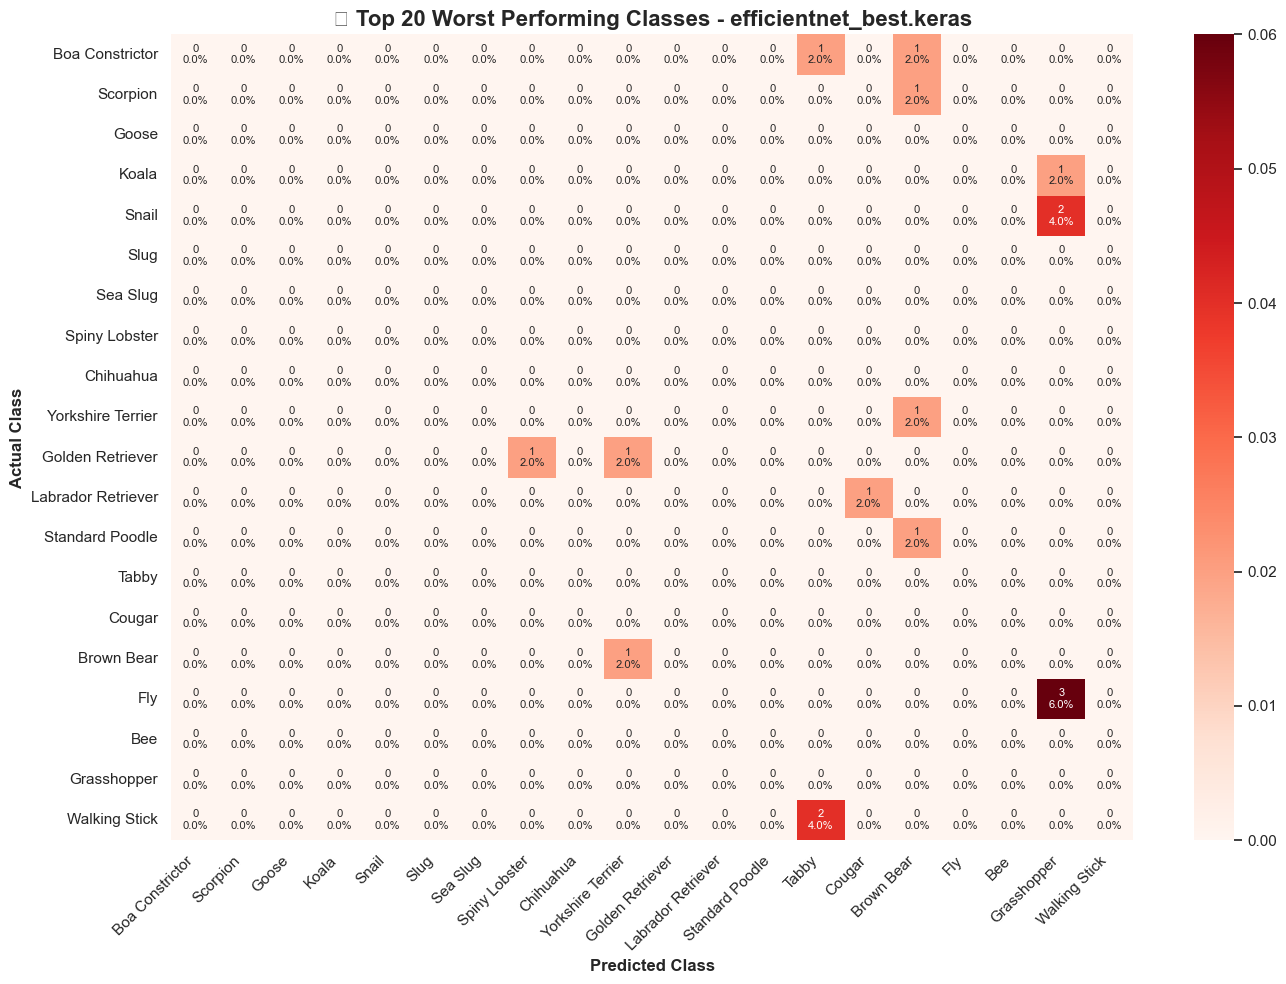


🚀 EVALUATING MODEL: baseline_resnet.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 129s 820ms/step

📜 Full Classification Report:
                          precision    recall  f1-score   support

                Goldfish       0.40      0.44      0.42        50
European Fire Salamander       0.18      0.32      0.23        50
                Bullfrog       0.08      0.24      0.11        50
             Tailed Frog       0.33      0.04      0.07        50
      American Alligator       0.18      0.08      0.11        50
         Boa Constrictor       0.06      0.06      0.06        50
               Trilobite       0.45      0.10      0.16        50
                Scorpion       0.00      0.00      0.00        50
             Black Widow       0.23      0.32      0.27        50
               Tarantula       0.50      0.02      0.04        50
               Centipede       0.05      0.02      0.03        50
                   Goose       0.09      0.26      0.13        50
                   Koa

/tmp/ipykernel_7620/3533707768.py:160: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


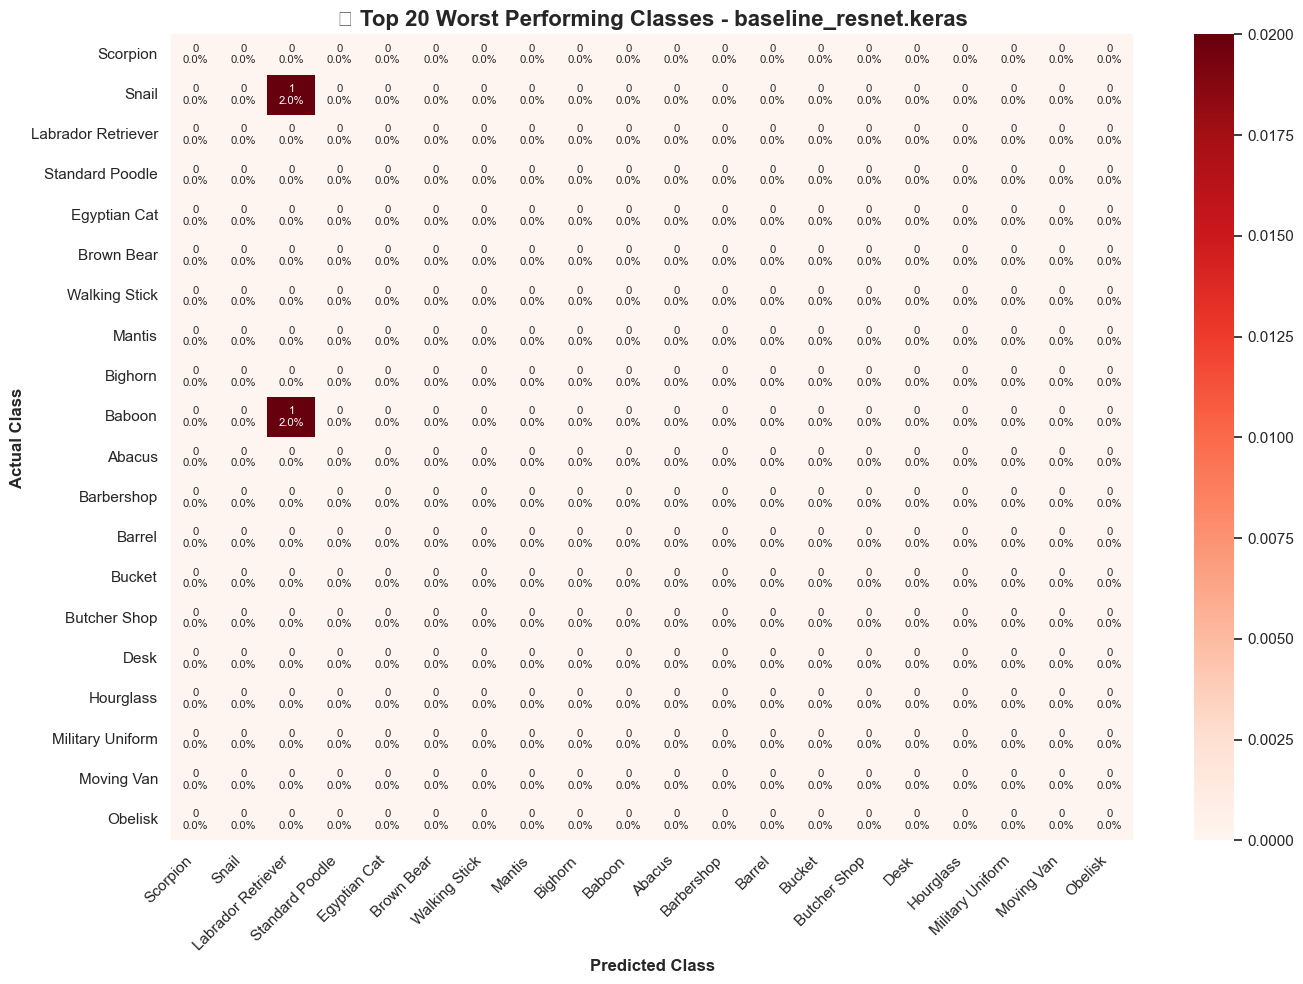


🚀 EVALUATING MODEL: vit_best.keras


/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step

📜 Full Classification Report:
                          precision    recall  f1-score   support

                Goldfish       0.18      0.38      0.24        50
European Fire Salamander       0.04      0.06      0.05        50
                Bullfrog       0.04      0.06      0.05        50
             Tailed Frog       0.00      0.00      0.00        50
      American Alligator       0.11      0.14      0.13        50
         Boa Constrictor       0.00      0.00      0.00        50
               Trilobite       0.03      0.04      0.04        50
                Scorpion       0.03      0.02      0.02        50
             Black Widow       0.06      0.08      0.07        50
               Tarantula       0.02      0.02      0.02        50
               Centipede       0.03      0.02      0.02        50
                   Goose       0.00      0.00      0.00        50
                   Koala       0.05      0.12      0.07        50


/tmp/ipykernel_7620/3533707768.py:160: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


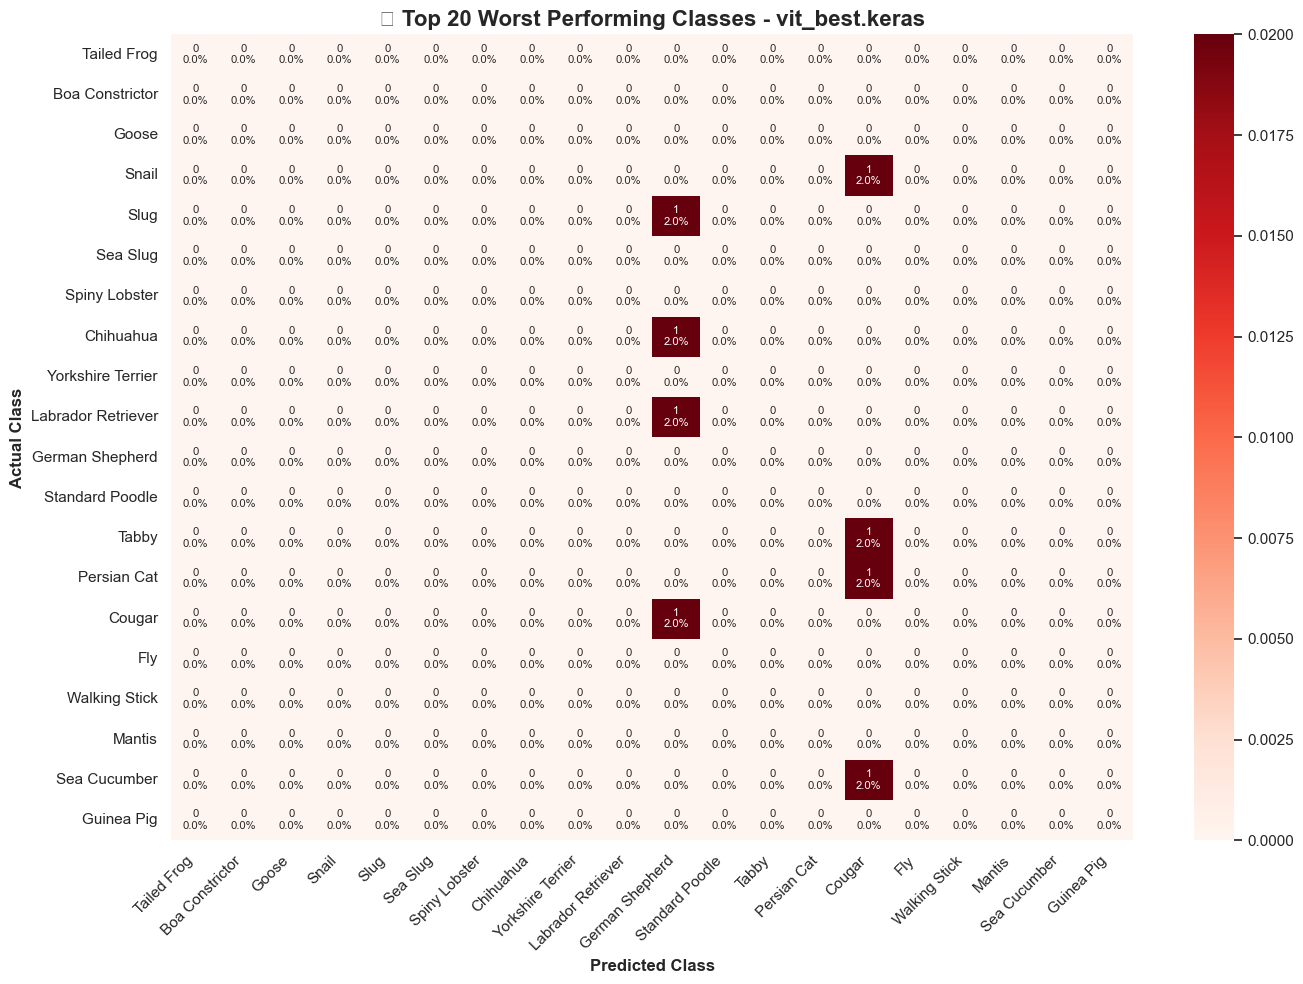

'\n# Cell 6: Detailed Classification Report & "Worst 20" Confusion Matrix\nimport os\nimport glob\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nimport keras\nfrom sklearn.metrics import classification_report, confusion_matrix\n\n# ==========================================\n# 1. CONFIGURATION & DICTIONARY MAPPING\n# ==========================================\nMODELS_DIR = os.path.join(PROJECT_ROOT, "models")\nVAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")\nWORDS_PATH = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "words.txt")\n\nlabel_map = {}\nif os.path.exists(WORDS_PATH):\n    with open(WORDS_PATH, "r") as f:\n        for line in f:\n            parts = line.strip().split("\t")\n            if len(parts) == 2:\n                label_map[parts[0]] = parts[1].split(",")[0].title()\n\n# Map the 200 class folders to their English names\nclass_folders = sorted([d for d in os.listdir(VAL_DIR) if os.path.isdir(os.path.join

In [24]:
# Cell 6: Detailed Classification Report & "Worst 20" Confusion Matrix
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 0. THE VISION TRANSFORMER (ViT) FIX
# ==========================================
# Ensure the notebook can see the src folder
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    
# Import your custom layers
from src.models import Patches, PatchEncoder 

# --- THE MONKEY PATCH ---
# We intercept the Keras config and delete base layer parameters 
# so your custom __init__ functions don't crash!
@classmethod
def safe_from_config(cls, config):
    config.pop('trainable', None)
    config.pop('dtype', None)
    config.pop('name', None)
    return cls(**config)

# Apply the patch to your custom classes
Patches.from_config = safe_from_config
PatchEncoder.from_config = safe_from_config

# ==========================================
# 1. CONFIGURATION & DICTIONARY MAPPING
# ==========================================
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")
WORDS_PATH = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "words.txt")

label_map = {}
if os.path.exists(WORDS_PATH):
    with open(WORDS_PATH, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                label_map[parts[0]] = parts[1].split(",")[0].title()

# Map the 200 class folders to their English names
class_folders = sorted([d for d in os.listdir(VAL_DIR) if os.path.isdir(os.path.join(VAL_DIR, d))])
english_class_names = [label_map.get(folder, folder) for folder in class_folders]

# ==========================================
# 1.5 FIX KERAS EXTENSION BUG
# ==========================================
uppercase_jpegs = glob.glob(os.path.join(VAL_DIR, "**", "*.JPEG"), recursive=True)
if uppercase_jpegs:
    print(f"🔧 Renaming {len(uppercase_jpegs)} uppercase .JPEG files to lowercase .jpeg for Keras compatibility...")
    for img_path in uppercase_jpegs:
        os.rename(img_path, img_path[:-5] + ".jpeg")

# ==========================================
# 2. LOAD VALIDATION DATA (SHUFFLE = FALSE)
# ==========================================
print("📂 Loading Validation Data...")
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    label_mode='categorical',
    image_size=(64, 64),
    batch_size=64, 
    shuffle=False # Critical for alignment with y_true
)

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

# ==========================================
# 3. AUTOMATED MODEL EVALUATION LOOP
# ==========================================
model_files = glob.glob(os.path.join(MODELS_DIR, "*.keras"))

if not model_files:
    print(f"⚠️ No .keras models found in {MODELS_DIR}")
else:
    for model_path in model_files:
        model_name = os.path.basename(model_path)
        print("\n" + "="*60)
        print(f"🚀 EVALUATING MODEL: {model_name}")
        print("="*60)
        
        # --- FEED THE CUSTOM BLUEPRINTS TO KERAS ---
        try:
            model = keras.models.load_model(
                model_path, 
                compile=False,
                custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
            )
        except Exception as e:
            print(f"❌ Failed to load {model_name}. Error: {e}")
            continue
            
        y_pred_probs = model.predict(val_ds, verbose=1)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        
        print("\n📜 Full Classification Report:")
        class_indices = np.arange(len(english_class_names))
        
        report_dict = classification_report(
            y_true_classes, y_pred_classes, 
            labels=class_indices, target_names=english_class_names, 
            output_dict=True, zero_division=0
        )
        print(classification_report(
            y_true_classes, y_pred_classes, 
            labels=class_indices, target_names=english_class_names, 
            zero_division=0
        ))
        
        # --- THE "WORST 20" CONFUSION MATRIX ---
        class_metrics = {k: v for k, v in report_dict.items() if k not in ['accuracy', 'macro avg', 'weighted avg']}
        sorted_classes = sorted(class_metrics.items(), key=lambda x: x[1]['f1-score'])
        worst_20_classes = sorted_classes[:20]
        
        worst_20_names = [item[0] for item in worst_20_classes]
        worst_20_indices = [english_class_names.index(name) for name in worst_20_names]
        
        cm_full = confusion_matrix(y_true_classes, y_pred_classes, labels=class_indices)
        cm_subset = cm_full[np.ix_(worst_20_indices, worst_20_indices)]
        
        row_sums = cm_full.sum(axis=1)
        row_sums_subset = row_sums[worst_20_indices]
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_percent = cm_subset.astype('float') / row_sums_subset[:, np.newaxis]
            cm_percent = np.nan_to_num(cm_percent) 
            
        labels = np.array([
            ["{0}\n{1:.1f}%".format(count, perc * 100) for count, perc in zip(row_counts, row_perc)]
            for row_counts, row_perc in zip(cm_subset, cm_percent)
        ])
        
        plt.figure(figsize=(14, 10))
        sns.heatmap(
            cm_percent, 
            annot=labels, 
            fmt='', 
            cmap='Reds', 
            xticklabels=worst_20_names, 
            yticklabels=worst_20_names,
            annot_kws={"size": 8} 
        )
        
        plt.xlabel("Predicted Class", fontsize=12, fontweight='bold')
        plt.ylabel("Actual Class", fontsize=12, fontweight='bold')
        plt.title(f"🚨 Top 20 Worst Performing Classes - {model_name}", fontsize=16, fontweight='bold')
        
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        
        plt.tight_layout()
        plt.show()


In [26]:
# Cell 7: Advanced Network Comparison (Precision, Recall, F1, & Hardware Efficiency)
import os
import sys
import glob
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import keras

# --- 1. HANDLE CUSTOM VIT ARCHITECTURE ---
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
from src.models import Patches, PatchEncoder 

@classmethod
def safe_from_config(cls, config):
    config.pop('trainable', None)
    config.pop('dtype', None)
    config.pop('name', None)
    return cls(**config)

Patches.from_config = safe_from_config
PatchEncoder.from_config = safe_from_config

# --- 2. CONFIGURATION ---
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")

print("📂 Loading Validation Data for aggregate comparison...")
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=(64, 64), batch_size=64, shuffle=False
)
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

model_files = glob.glob(os.path.join(MODELS_DIR, "*.keras"))
comparison_data = []

# --- 3. EVALUATION LOOP ---
if not model_files:
    print(f"⚠️ No .keras models found in {MODELS_DIR}")
else:
    for model_path in model_files:
        model_name = os.path.basename(model_path).replace(".keras", "")
        print(f"🚀 Processing metrics for: {model_name}...")
        
        # Load Model
        try:
            model = keras.models.load_model(
                model_path, compile=False, 
                custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
            )
        except Exception as e:
            print(f"❌ Skipping {model_name}: {e}")
            continue
            
        # Run Inference
        y_pred_probs = model.predict(val_ds, verbose=0)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        
        # Metric 1: Precision, Recall, F1 (Macro Average)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average='macro', zero_division=0
        )
        
        # Metric 2: Top-1 Accuracy
        top1_acc = np.mean(y_true_classes == y_pred_classes)
        
        # Metric 3: Top-5 Accuracy (Is the true class in the top 5 highest probabilities?)
        top5_acc = np.mean(
            [y_true_classes[i] in np.argsort(y_pred_probs[i])[-5:] for i in range(len(y_true_classes))]
        )
        
        # Metric 4: Hardware Footprint (Total Parameters)
        param_count = model.count_params()
        
        comparison_data.append({
            "Model": model_name.title(),
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Top1_Acc": top1_acc,
            "Top5_Acc": top5_acc,
            "Parameters": param_count
        })

    # --- 4. RENDER DASHBOARDS ---
    df_results = pd.DataFrame(comparison_data)
    print("\n📊 Generating Comparison Dashboards...")
    
    # Dashboard 1: Precision, Recall, F1
    fig_metrics = go.Figure(data=[
        go.Bar(name='Precision', x=df_results['Model'], y=df_results['Precision'], marker_color='indianred'),
        go.Bar(name='Recall', x=df_results['Model'], y=df_results['Recall'], marker_color='lightsalmon'),
        go.Bar(name='F1-Score', x=df_results['Model'], y=df_results['F1_Score'], marker_color='steelblue')
    ])
    fig_metrics.update_layout(
        title="<b>🎯 Macro-Metrics Comparison across Architectures</b>", 
        barmode='group', template='plotly_white', yaxis=dict(title="Score")
    )
    fig_metrics.show()

    # Dashboard 2: Top-1 vs Top-5 Accuracy
    fig_acc = go.Figure(data=[
        go.Bar(name='Top-1 Accuracy', x=df_results['Model'], y=df_results['Top1_Acc'], marker_color='teal'),
        go.Bar(name='Top-5 Accuracy', x=df_results['Model'], y=df_results['Top5_Acc'], marker_color='lightseagreen')
    ])
    fig_acc.update_layout(
        title="<b>🥇 Top-1 vs Top-5 Accuracy (ImageNet Standard)</b>", 
        barmode='group', template='plotly_white', yaxis=dict(title="Accuracy")
    )
    fig_acc.show()
    
    # Dashboard 3: Hardware Efficiency
    fig_hw = px.scatter(
        df_results, x='Parameters', y='F1_Score', color='Model', size='Top5_Acc',
        title="<b>⚙️ Hardware Efficiency: Parameter Count vs F1-Score</b>",
        labels={'Parameters': 'Total Model Parameters', 'F1_Score': 'Macro F1-Score'},
        template='plotly_white', size_max=40
    )
    fig_hw.update_traces(marker=dict(line=dict(width=2, color='DarkSlateGrey')))
    fig_hw.show()

📂 Loading Validation Data for aggregate comparison...
Found 10000 files belonging to 200 classes.
🚀 Processing metrics for: efficientnet_best...
🚀 Processing metrics for: baseline_resnet...
🚀 Processing metrics for: vit_best...


/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'patch_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



📊 Generating Comparison Dashboards...


# Evaluations

In [27]:
# Cell 7.1: Table 1 - Core Classification Metrics
import os
import sys
import glob
import numpy as np
import pandas as pd
import keras
from sklearn.metrics import recall_score, f1_score
from IPython.display import display, Markdown

# ==========================================
# 0. THE VISION TRANSFORMER (ViT) FIX
# ==========================================
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
from src.models import Patches, PatchEncoder 

@classmethod
def safe_from_config(cls, config):
    config.pop('trainable', None)
    config.pop('dtype', None)
    config.pop('name', None)
    return cls(**config)

Patches.from_config = safe_from_config
PatchEncoder.from_config = safe_from_config

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")

print("📂 Loading Validation Data for Table 1...")
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=(64, 64), batch_size=64, shuffle=False
)

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

# Initialize the Categorical Cross-Entropy Loss function
cce_loss = keras.losses.CategoricalCrossentropy()

model_files = glob.glob(os.path.join(MODELS_DIR, "*.keras"))
table1_data = []

# ==========================================
# 2. EVALUATION LOOP
# ==========================================
if not model_files:
    print(f"⚠️ No .keras models found in {MODELS_DIR}")
else:
    for model_path in model_files:
        model_name = os.path.basename(model_path).replace(".keras", "")
        print(f"🚀 Processing Core Metrics for: {model_name}...")
        
        try:
            model = keras.models.load_model(
                model_path, compile=False, 
                custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
            )
        except Exception as e:
            print(f"❌ Skipping {model_name}: {e}")
            continue
            
        # Run Inference
        y_pred_probs = model.predict(val_ds, verbose=0)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        
        # 1. Validation Loss
        val_loss = cce_loss(y_true, y_pred_probs).numpy()
        
        # 2. Standard Top-1 Accuracy
        standard_acc = np.mean(y_true_classes == y_pred_classes)
        
        # 3. High-Confidence Accuracy (>90%)
        max_probs = np.max(y_pred_probs, axis=1)
        correct_and_confident = np.sum((y_pred_classes == y_true_classes) & (max_probs >= 0.90))
        high_conf_acc = correct_and_confident / len(y_true_classes)
        
        # 4. Macro Recall
        macro_recall = recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        
        # 5. Macro F1-Score
        macro_f1 = f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
        
        table1_data.append({
            "Architecture": model_name.title(),
            "Val Loss ↓": val_loss,
            "Standard Acc ↑": f"{standard_acc*100:.2f}%",
            "High-Conf Acc (>90%) ↑": f"{high_conf_acc*100:.2f}%",
            "Macro Recall ↑": f"{macro_recall*100:.2f}%",
            "Macro F1-Score ↑": f"{macro_f1*100:.2f}%"
        })

    # ==========================================
    # 3. RENDER TABLE 1
    # ==========================================
    df_table1 = pd.DataFrame(table1_data)
    # Sort by the best F1-Score
    df_table1 = df_table1.sort_values(by="Macro F1-Score ↑", ascending=False)
    
    display(Markdown("### 📊 Table 1: Core Classification Metrics"))
    # Apply a sleek gradient background to the Loss column to highlight the lowest numbers
    styled_table1 = df_table1.style.background_gradient(subset=["Val Loss ↓"], cmap="YlOrRd").hide(axis="index")
    display(styled_table1)

📂 Loading Validation Data for Table 1...
Found 10000 files belonging to 200 classes.
🚀 Processing Core Metrics for: efficientnet_best...
🚀 Processing Core Metrics for: baseline_resnet...
🚀 Processing Core Metrics for: vit_best...


/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


### 📊 Table 1: Core Classification Metrics

Architecture,Val Loss ↓,Standard Acc ↑,High-Conf Acc (>90%) ↑,Macro Recall ↑,Macro F1-Score ↑
Vit_Best,4.562417,7.76%,0.00%,7.76%,4.81%
Efficientnet_Best,4.521131,6.78%,0.00%,6.78%,4.35%
Baseline_Resnet,3.930552,15.06%,0.39%,15.06%,12.26%


In [28]:
# Cell 7.2: Part 2 - Advanced Statistical Robustness
import os
import sys
import glob
import numpy as np
import pandas as pd
import keras
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

# ==========================================
# 0. THE VISION TRANSFORMER (ViT) FIX
# ==========================================
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
from src.models import Patches, PatchEncoder 

@classmethod
def safe_from_config(cls, config):
    config.pop('trainable', None)
    config.pop('dtype', None)
    config.pop('name', None)
    return cls(**config)

Patches.from_config = safe_from_config
PatchEncoder.from_config = safe_from_config

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")

print("📂 Loading Validation Data for Part 2...")
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=(64, 64), batch_size=64, shuffle=False
)

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

model_files = glob.glob(os.path.join(MODELS_DIR, "*.keras"))
robustness_data = []

# ==========================================
# 2. EVALUATION LOOP
# ==========================================
if not model_files:
    print(f"⚠️ No .keras models found in {MODELS_DIR}")
else:
    for model_path in model_files:
        model_name = os.path.basename(model_path).replace(".keras", "")
        print(f"🚀 Processing Robustness Metrics for: {model_name}...")
        
        try:
            model = keras.models.load_model(
                model_path, compile=False, 
                custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
            )
        except Exception as e:
            print(f"❌ Skipping {model_name}: {e}")
            continue
            
        # Run Inference
        y_pred_probs = model.predict(val_ds, verbose=0)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        
        # 1. Top-20 Accuracy (Vectorized for maximum speed)
        # Gets the indices of the top 20 probabilities for every single image
        top20_preds = np.argsort(y_pred_probs, axis=1)[:, -20:]
        # Checks if the true class is anywhere inside those top 20 predictions
        top20_acc = np.mean(np.any(top20_preds == y_true_classes[:, None], axis=1))
        
        # 2. Matthews Correlation Coefficient (MCC)
        mcc = matthews_corrcoef(y_true_classes, y_pred_classes)
        
        # 3. Cohen's Kappa
        kappa = cohen_kappa_score(y_true_classes, y_pred_classes)
        
        robustness_data.append({
            "Model": model_name.title(),
            "Top20_Acc": top20_acc,
            "MCC": mcc,
            "Kappa": kappa
        })

    # ==========================================
    # 3. RENDER VISUAL DASHBOARDS
    # ==========================================
    df_robust = pd.DataFrame(robustness_data)
    
    # We create a layout with 1 row and 2 columns for a clean, side-by-side dashboard
    fig = make_subplots(
        rows=1, cols=2, 
        subplot_titles=("<b>📈 Top-20 Accuracy (Top 10% Bracket)</b>", "<b>⚖️ Statistical Reliability (MCC & Kappa)</b>"),
        horizontal_spacing=0.15
    )

    # Left Chart: Top-20 Accuracy
    fig.add_trace(
        go.Bar(
            x=df_robust['Model'], y=df_robust['Top20_Acc'], 
            marker_color='mediumpurple', name='Top-20 Acc',
            text=[f"{val*100:.1f}%" for val in df_robust['Top20_Acc']],
            textposition='auto'
        ),
        row=1, col=1
    )

    # Right Chart: MCC and Kappa comparison
    fig.add_trace(
        go.Bar(
            x=df_robust['Model'], y=df_robust['MCC'], 
            marker_color='royalblue', name='MCC'
        ),
        row=1, col=2
    )
    fig.add_trace(
        go.Bar(
            x=df_robust['Model'], y=df_robust['Kappa'], 
            marker_color='lightseagreen', name='Cohen\'s Kappa'
        ),
        row=1, col=2
    )

    fig.update_layout(
        title_text="<b>🛡️ Part 2: Advanced Statistical Robustness Dashboard</b>",
        template='plotly_white',
        barmode='group',
        height=500
    )
    
    # Update Y-axes for readability
    fig.update_yaxes(title_text="Accuracy", range=[0, 1], row=1, col=1)
    fig.update_yaxes(title_text="Score (-1 to 1)", range=[-1.1, 1.1], row=1, col=2)

    fig.show()

📂 Loading Validation Data for Part 2...
Found 10000 files belonging to 200 classes.


2026-03-09 07:57:57.809387: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🚀 Processing Robustness Metrics for: efficientnet_best...
🚀 Processing Robustness Metrics for: baseline_resnet...
🚀 Processing Robustness Metrics for: vit_best...


/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'patch_encoder_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [29]:
# Cell 7.3: Per-Class Accuracy Comparison Table
import os
import sys
import glob
import numpy as np
import pandas as pd
import keras
from IPython.display import display, Markdown

# ==========================================
# 0. THE VISION TRANSFORMER (ViT) FIX
# ==========================================
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
from src.models import Patches, PatchEncoder 

@classmethod
def safe_from_config(cls, config):
    config.pop('trainable', None)
    config.pop('dtype', None)
    config.pop('name', None)
    return cls(**config)

Patches.from_config = safe_from_config
PatchEncoder.from_config = safe_from_config

# ==========================================
# 1. CONFIGURATION & DICTIONARY MAPPING
# ==========================================
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")
WORDS_PATH = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "words.txt")

label_map = {}
if os.path.exists(WORDS_PATH):
    with open(WORDS_PATH, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                label_map[parts[0]] = parts[1].split(",")[0].title()

# Map the 200 class folders to their English names
class_folders = sorted([d for d in os.listdir(VAL_DIR) if os.path.isdir(os.path.join(VAL_DIR, d))])
english_class_names = [label_map.get(folder, folder) for folder in class_folders]

# ==========================================
# 2. LOAD VALIDATION DATA
# ==========================================
print("📂 Loading Validation Data for Class Breakdown...")
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=(64, 64), batch_size=64, shuffle=False
)

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

model_files = sorted(glob.glob(os.path.join(MODELS_DIR, "*.keras")))

# Initialize a dictionary to hold our columns
# Format: {"Beaver": [acc_model1, acc_model2, ...], ...}
class_accuracies = {class_name: [] for class_name in english_class_names}
model_names = []

# ==========================================
# 3. EVALUATION LOOP
# ==========================================
if not model_files:
    print(f"⚠️ No .keras models found in {MODELS_DIR}")
else:
    for model_path in model_files:
        model_name = os.path.basename(model_path).replace(".keras", "").title()
        model_names.append(model_name)
        print(f"🚀 Extracting Class Accuracies for: {model_name}...")
        
        try:
            model = keras.models.load_model(
                model_path, compile=False, 
                custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
            )
        except Exception as e:
            print(f"❌ Skipping {model_name}: {e}")
            # Append a column of zeros if the model fails to load so the table doesn't break
            for class_name in english_class_names:
                class_accuracies[class_name].append(0.0)
            continue
            
        # Run Inference
        y_pred_probs = model.predict(val_ds, verbose=0)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        
        # Calculate accuracy for each of the 200 classes
        for class_idx, class_name in enumerate(english_class_names):
            # Find all images that actually belong to this class
            true_indices = (y_true_classes == class_idx)
            total_in_class = np.sum(true_indices)
            
            if total_in_class > 0:
                # Count how many of those specific images the model got right
                correct_predictions = np.sum(y_pred_classes[true_indices] == class_idx)
                acc = (correct_predictions / total_in_class) * 100.0 # Convert to percentage
            else:
                acc = 0.0
                
            class_accuracies[class_name].append(acc)

    # ==========================================
    # 4. RENDER THE MASTER TABLE
    # ==========================================
    # Convert our dictionary to a Pandas DataFrame
    df_class_breakdown = pd.DataFrame.from_dict(class_accuracies, orient='index', columns=model_names)
    df_class_breakdown.index.name = "Category"
    
    display(Markdown("### 🏆 Fine-Grained Accuracy Leaderboard (Per Category)"))
    
    # Pandas Styling: We highlight the maximum value in each row (axis=1) with green text and bold font
    styled_df = df_class_breakdown.style.highlight_max(
        axis=1, 
        props='color: darkgreen; font-weight: bold; background-color: lightgreen;'
    ).format("{:.1f}%") # Format all numbers to have one decimal and a percentage sign
    
    display(styled_df)

📂 Loading Validation Data for Class Breakdown...
Found 10000 files belonging to 200 classes.
🚀 Extracting Class Accuracies for: Baseline_Resnet...
🚀 Extracting Class Accuracies for: Efficientnet_Best...
🚀 Extracting Class Accuracies for: Vit_Best...


/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'patch_encoder_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


### 🏆 Fine-Grained Accuracy Leaderboard (Per Category)

,Baseline_Resnet,Efficientnet_Best,Vit_Best
Category,,,
Goldfish,44.0%,18.0%,38.0%
European Fire Salamander,32.0%,10.0%,6.0%
Bullfrog,24.0%,8.0%,6.0%
Tailed Frog,4.0%,4.0%,0.0%
American Alligator,8.0%,8.0%,14.0%
Boa Constrictor,6.0%,0.0%,0.0%
Trilobite,10.0%,8.0%,4.0%
Scorpion,0.0%,0.0%,2.0%
Black Widow,32.0%,14.0%,8.0%


In [30]:
# Cell 7.4: Part 3 - Confidence & Reliability (ECE & AUC-ROC)
import os
import sys
import glob
import numpy as np
import pandas as pd
import keras
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_auc_score

# ==========================================
# 0. THE VISION TRANSFORMER (ViT) FIX
# ==========================================
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
from src.models import Patches, PatchEncoder 

@classmethod
def safe_from_config(cls, config):
    config.pop('trainable', None)
    config.pop('dtype', None)
    config.pop('name', None)
    return cls(**config)

Patches.from_config = safe_from_config
PatchEncoder.from_config = safe_from_config

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")

print("📂 Loading Validation Data for Part 3...")
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=(64, 64), batch_size=64, shuffle=False
)

# y_true is one-hot encoded (required for AUC-ROC)
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

model_files = glob.glob(os.path.join(MODELS_DIR, "*.keras"))
reliability_data = []

# ==========================================
# 2. EVALUATION LOOP
# ==========================================
if not model_files:
    print(f"⚠️ No .keras models found in {MODELS_DIR}")
else:
    for model_path in model_files:
        model_name = os.path.basename(model_path).replace(".keras", "").title()
        print(f"🚀 Processing Reliability Metrics for: {model_name}...")
        
        try:
            model = keras.models.load_model(
                model_path, compile=False, 
                custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
            )
        except Exception as e:
            print(f"❌ Skipping {model_name}: {e}")
            continue
            
        # Run Inference
        y_pred_probs = model.predict(val_ds, verbose=0)
        
        # --- Metric 1: Expected Calibration Error (ECE) ---
        confidences = np.max(y_pred_probs, axis=1)
        predictions = np.argmax(y_pred_probs, axis=1)
        accuracies = (predictions == y_true_classes)
        
        # Split into 10 confidence bins (0.0 to 1.0)
        num_bins = 10
        bins = np.linspace(0.0, 1.0, num_bins + 1)
        bin_indices = np.digitize(confidences, bins, right=True)
        
        ece = 0.0
        for b in range(1, num_bins + 1):
            mask = bin_indices == b
            if np.any(mask):
                bin_accuracy = np.mean(accuracies[mask])
                bin_confidence = np.mean(confidences[mask])
                bin_weight = np.sum(mask) / len(confidences)
                ece += bin_weight * np.abs(bin_accuracy - bin_confidence)
                
        # --- Metric 2: Macro AUC-ROC (One-vs-Rest) ---
        # Note: If a model hasn't trained enough to predict all classes, AUC-ROC might throw a warning.
        try:
            auc_roc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')
        except ValueError:
            # Fallback if the model predicts essentially zero for some classes (common in 1-epoch dry runs)
            auc_roc = 0.0 
            
        reliability_data.append({
            "Model": model_name,
            "ECE": ece,
            "AUC_ROC": auc_roc
        })

    # ==========================================
    # 3. RENDER VISUAL DASHBOARDS
    # ==========================================
    df_rel = pd.DataFrame(reliability_data)
    
    fig = make_subplots(
        rows=1, cols=2, 
        subplot_titles=("<b>🎯 Expected Calibration Error (Lower is Better)</b>", "<b>📈 Macro AUC-ROC (Higher is Better)</b>"),
        horizontal_spacing=0.15
    )

    # Left Chart: ECE
    fig.add_trace(
        go.Bar(
            x=df_rel['Model'], y=df_rel['ECE'], 
            marker_color='crimson', name='ECE',
            text=[f"{val*100:.2f}%" for val in df_rel['ECE']],
            textposition='auto'
        ),
        row=1, col=1
    )

    # Right Chart: AUC-ROC
    fig.add_trace(
        go.Bar(
            x=df_rel['Model'], y=df_rel['AUC_ROC'], 
            marker_color='forestgreen', name='AUC-ROC',
            text=[f"{val:.3f}" for val in df_rel['AUC_ROC']],
            textposition='auto'
        ),
        row=1, col=2
    )

    fig.update_layout(
        title_text="<b>🔎 Part 3: Model Confidence & Reliability Dashboard</b>",
        template='plotly_white',
        barmode='group',
        height=500
    )
    
    fig.update_yaxes(title_text="Calibration Error Gap", range=[0, max(df_rel['ECE'].max() * 1.2, 0.1)], row=1, col=1)
    fig.update_yaxes(title_text="AUC Score", range=[0, 1], row=1, col=2)

    fig.show()

📂 Loading Validation Data for Part 3...
Found 10000 files belonging to 200 classes.
🚀 Processing Reliability Metrics for: Efficientnet_Best...
🚀 Processing Reliability Metrics for: Baseline_Resnet...
🚀 Processing Reliability Metrics for: Vit_Best...


/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'patch_encoder_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [31]:
# Cell 7.5: Part 4 - Hardware & Deployment Metrics
import os
import sys
import glob
import time
import numpy as np
import pandas as pd
import keras
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown

# ==========================================
# 0. THE VISION TRANSFORMER (ViT) FIX
# ==========================================
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
from src.models import Patches, PatchEncoder 

@classmethod
def safe_from_config(cls, config):
    config.pop('trainable', None)
    config.pop('dtype', None)
    config.pop('name', None)
    return cls(**config)

Patches.from_config = safe_from_config
PatchEncoder.from_config = safe_from_config

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
VAL_DIR = os.path.join(PROJECT_ROOT, "data", "tiny-imagenet-200", "val")

print("📂 Loading Validation Data for Latency Testing...")
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=(64, 64), batch_size=64, shuffle=False
)

# Extract a single batch of 64 images for speed testing
sample_images, _ = next(iter(val_ds))

model_files = glob.glob(os.path.join(MODELS_DIR, "*.keras"))
hardware_data = []

# ==========================================
# 2. HARDWARE EVALUATION LOOP
# ==========================================
if not model_files:
    print(f"⚠️ No .keras models found in {MODELS_DIR}")
else:
    for model_path in model_files:
        model_name = os.path.basename(model_path).replace(".keras", "").title()
        print(f"🚀 Profiling Hardware Metrics for: {model_name}...")
        
        try:
            model = keras.models.load_model(
                model_path, compile=False, 
                custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
            )
        except Exception as e:
            print(f"❌ Skipping {model_name}: {e}")
            continue
            
        # 1. Model Size on Disk (MB)
        file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
        
        # 2. Parameter Count (Millions)
        total_params = model.count_params()
        params_millions = total_params / 1_000_000
        
        # 3. Inference Latency (ms per image)
        # WARM-UP: Neural networks are slow on the first pass. We run it once and ignore the time.
        _ = model.predict(sample_images, verbose=0)
        
        # TIMED RUN: Run inference 10 times to get a stable average
        num_runs = 10
        start_time = time.time()
        for _ in range(num_runs):
            _ = model.predict(sample_images, verbose=0)
        end_time = time.time()
        
        # Calculate time: Total time / (10 runs * 64 images per batch) -> convert to milliseconds
        avg_time_per_image_ms = ((end_time - start_time) / (num_runs * 64)) * 1000
        
        hardware_data.append({
            "Architecture": model_name,
            "Size (MB) ↓": file_size_mb,
            "Parameters (Millions) ↓": params_millions,
            "Latency (ms/image) ↓": avg_time_per_image_ms
        })

    # ==========================================
    # 3. RENDER VISUAL DASHBOARD
    # ==========================================
    df_hw = pd.DataFrame(hardware_data)
    
    fig = make_subplots(
        rows=1, cols=3, 
        subplot_titles=("<b>💾 Disk Size (MB)</b>", "<b>🧠 Parameters (Millions)</b>", "<b>⚡ Latency (ms/image)</b>"),
        horizontal_spacing=0.1
    )

    # Chart 1: Size
    fig.add_trace(go.Bar(x=df_hw['Architecture'], y=df_hw['Size (MB) ↓'], marker_color='slategray', name='Size', text=[f"{val:.1f} MB" for val in df_hw['Size (MB) ↓']], textposition='auto'), row=1, col=1)
    
    # Chart 2: Parameters
    fig.add_trace(go.Bar(x=df_hw['Architecture'], y=df_hw['Parameters (Millions) ↓'], marker_color='royalblue', name='Params', text=[f"{val:.1f}M" for val in df_hw['Parameters (Millions) ↓']], textposition='auto'), row=1, col=2)
    
    # Chart 3: Latency
    fig.add_trace(go.Bar(x=df_hw['Architecture'], y=df_hw['Latency (ms/image) ↓'], marker_color='goldenrod', name='Latency', text=[f"{val:.2f} ms" for val in df_hw['Latency (ms/image) ↓']], textposition='auto'), row=1, col=3)

    fig.update_layout(title_text="<b>⚙️ Part 4: Enterprise Deployment & Hardware Footprint</b>", template='plotly_white', showlegend=False, height=450)
    fig.show()

    # ==========================================
    # 4. RENDER DEPLOYMENT TABLE
    # ==========================================
    display(Markdown("### 🚀 Production Deployment Leaderboard (Lower is Better)"))
    
    # Format the table for the hiring manager
    styled_df_hw = df_hw.style.format({
        "Size (MB) ↓": "{:.2f} MB",
        "Parameters (Millions) ↓": "{:.2f} M",
        "Latency (ms/image) ↓": "{:.2f} ms"
    }).background_gradient(cmap="Blues").hide(axis="index")
    
    display(styled_df_hw)

📂 Loading Validation Data for Latency Testing...
Found 10000 files belonging to 200 classes.
🚀 Profiling Hardware Metrics for: Efficientnet_Best...
🚀 Profiling Hardware Metrics for: Baseline_Resnet...
🚀 Profiling Hardware Metrics for: Vit_Best...


/home/victor/miniconda3/envs/vision_portfolio/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'patch_encoder_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


### 🚀 Production Deployment Leaderboard (Lower is Better)

Architecture,Size (MB) ↓,Parameters (Millions) ↓,Latency (ms/image) ↓
Efficientnet_Best,71.29 MB,6.18 M,1.79 ms
Baseline_Resnet,57.42 MB,5.01 M,9.50 ms
Vit_Best,7.42 MB,0.63 M,3.40 ms
